# Image Quality (QI) Analysis

In this notebook, the ....

# Packages

In [2]:
packages <- list("lme4", "glmmTMB", "ggeffects")
for (pack in packages) {
    if (!requireNamespace(pack, quietly = TRUE)) {
      print(paste('Installing', pack))
      install.packages(pack)
    }
}

In [3]:
library(readr)
library(lme4)
library(glmmTMB)
library(ggplot2)
library(ggeffects)

Loading required package: Matrix



# Read Dataset

In [4]:
dataset_v0 = read_csv("data/dataset/suited_dataset.csv", show_col_types = FALSE)
dim(dataset_v0)

[1] 1772    9

In [5]:
ds_qi_per_img = read_csv("output/qi_per_img_3.csv", show_col_types = FALSE)
dim(ds_qi_per_img)

[1] 1772    2

In [6]:
dataset_v1 = merge(x = dataset_v0, y = ds_qi_per_img, by='depth')
dim(dataset_v1)

[1] 1772   10

In [7]:
dataset_v1 <- dataset_v1[,-c(1, 5,6)]
head(dataset_v1)

,farm,animal_id,weight,captured_at_as_min,unexpected_behavior,gender,qi
,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>
1,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3305.927
2,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3338.609
3,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3289.363
4,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3317.456
5,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3379.749
6,Farm B,amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3374.645


In [8]:
dataset_v1$farm = ifelse(dataset_v1$farm == 'Farm A', "Morning (Farm A)", "Afternoon (Farm B)")

In [9]:
dataset_v1$farm  = as.factor(dataset_v1$farm)
dataset_v1$unexpected_behavior = as.factor(dataset_v1$unexpected_behavior)
dataset_v1$animal_id = as.factor(dataset_v1$animal_id)
dataset_v1$gender = as.factor(dataset_v1$gender)

head(dataset_v1)

,farm,animal_id,weight,captured_at_as_min,unexpected_behavior,gender,qi
,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<dbl>
1,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3305.927
2,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3338.609
3,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3289.363
4,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3317.456
5,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3379.749
6,Afternoon (Farm B),amQbSM2SqEHxySXmbNkB,44.3,1031,TRUE,1,3374.645


# Model Evaluation

....

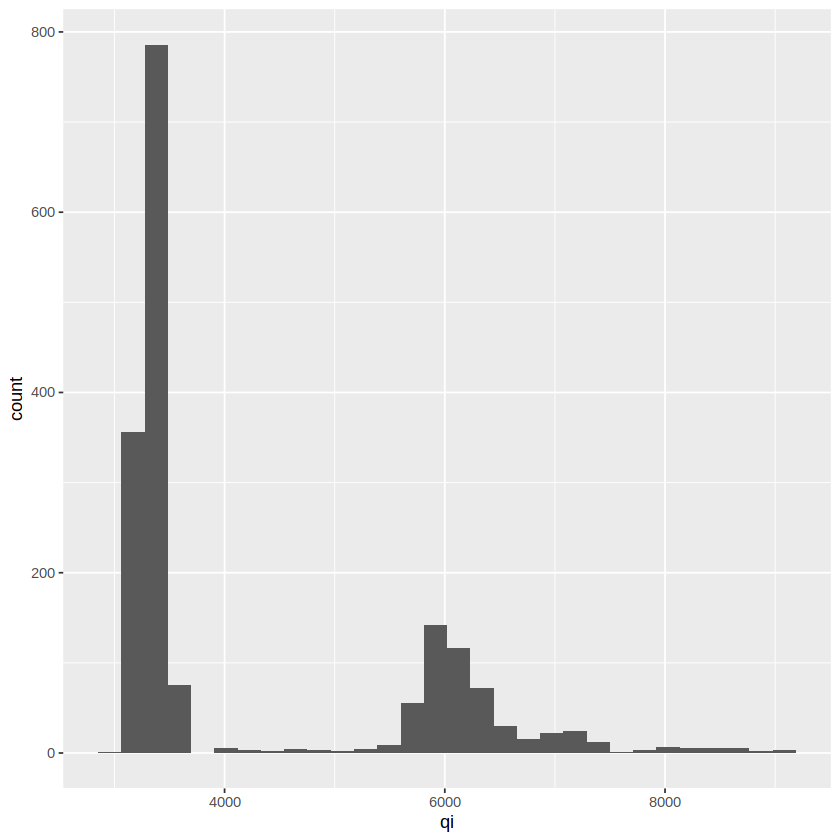

In [102]:
ggplot(dataset_v1, aes(x = qi)) + geom_histogram(bins = 30)

## Adjusting models

In [157]:
model1 <- lme4::glmer(
  'qi ~ farm + captured_at_as_min + weight + unexpected_behavior + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(model1)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.200536 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm + captured_at_as_min + weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

     AIC      BIC   logLik deviance df.resid 
 23262.3  23300.7 -11624.2  23248.3     1765 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3185 -0.2261 -0.0072  0.2182  6.4874 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.001406 0.03750 
 Residual              0.001857 0.04309 
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                           Estimate  Std. Error t value            Pr(>|z|)    
(Intercept)              8.27493642  0.02069146 399.920 <0.0000000000000002 ***
farmFarm B              -0.93667785  0.01470697 -63.689 <0.0000000000000002 ***
captured_at_as_min       0.00075759  0.00002044  37.063 <0.0000000000000002 ***
weight                  -0.00069088  0.00042969  -1

In [24]:
model2 <- lme4::glmer(
  'qi ~ farm * captured_at_as_min + weight + unexpected_behavior + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = 'log')
)
summary(model2)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 13.2391 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm * captured_at_as_min + weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

     AIC      BIC   logLik deviance df.resid 
 23256.9  23300.7 -11620.5  23240.9     1764 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3298 -0.2228 -0.0051  0.2149  6.4470 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.001309 0.03618 
 Residual              0.001830 0.04278 
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                                          Estimate Std. Error t value Pr(>|z|)
(Intercept)                              9.082e+00  2.441e-02 372.028  < 2e-16
farmMorning (Farm A)                    -8.636e-01  3.908e-02 -22.098  < 2e-16
captured_at_as_min                      -9.171e-04  1.891e-05 -48.489  < 2e-16
weight                                  -1.164e-03  4.1

In [18]:
model3 <- lme4::glmer(
  'qi ~ farm + captured_at_as_min * weight + unexpected_behavior + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = 'log')
)
summary(model3)

Warning message:
“Some predictor variables are on very different scales: consider rescaling”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 13.0935 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm + captured_at_as_min * weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

     AIC      BIC   logLik deviance df.resid 
 23261.6  23305.5 -11622.8  23245.6     1764 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3181 -0.2212 -0.0044  0.2229  6.4200 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.001370 0.03702 
 Residual              0.001845 0.04296 
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                            Estimate Std. Error t value Pr(>|z|)    
(Intercept)                7.442e+00  2.560e-02 290.686  < 2e-16 ***
farmMorning (Farm A)       9.331e-01  1.443e-02  64.664  < 2e-16 ***
captured_at_as_min         6.327e-04  1.991e-05  31.778  < 2e-16 ***
weight                    -3.619e-03  4.320e-04  -8.379  < 2e-16 ***
unexpected_behaviorTRUE   

In [21]:
model4 <- lme4::glmer(
  'qi ~ farm + captured_at_as_min * unexpected_behavior + weight + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = 'log')
)
summary(model4)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.198844 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm + captured_at_as_min * unexpected_behavior + weight +  
    (1 | animal_id)
   Data: dataset_v1

     AIC      BIC   logLik deviance df.resid 
 23264.2  23308.1 -11624.1  23248.2     1764 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3132 -0.2285 -0.0063  0.2154  6.4940 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.001405 0.03749 
 Residual              0.001857 0.04309 
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                                             Estimate Std. Error t value
(Intercept)                                 7.343e+00  2.616e-02 280.696
farmMorning (Farm A)                        9.331e-01  1.537e-02  60.704
captured_at_as_min                          7.549e-04  2.042e-05  36.959
unexpected_behaviorTRUE                     3.264e-02  4.616e-02   0.707
weight

In [22]:
model5 <- lme4::glmer(
  'qi ~ farm * captured_at_as_min * weight + unexpected_behavior + (1|animal_id)',
  data = dataset_v1,
  family = Gamma(link = 'log')
)
summary(model5)

Warning message:
“Some predictor variables are on very different scales: consider rescaling”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 9.18033 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: qi ~ farm * captured_at_as_min * weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

     AIC      BIC   logLik deviance df.resid 
 23261.9  23322.2 -11619.9  23239.9     1761 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3244 -0.2221 -0.0030  0.2172  6.4479 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.001304 0.03611 
 Residual              0.001830 0.04278 
Number of obs: 1772, groups:  animal_id, 190

Fixed effects:
                                                 Estimate Std. Error t value
(Intercept)                                     1.002e+01  2.875e-02 348.593
farmMorning (Farm A)                           -2.092e+00  4.787e-02 -43.706
captured_at_as_min                             -1.826e-03  1.879e-05 -97.159
weight                                         -4.528e-02  6.30

## Effect Analysis

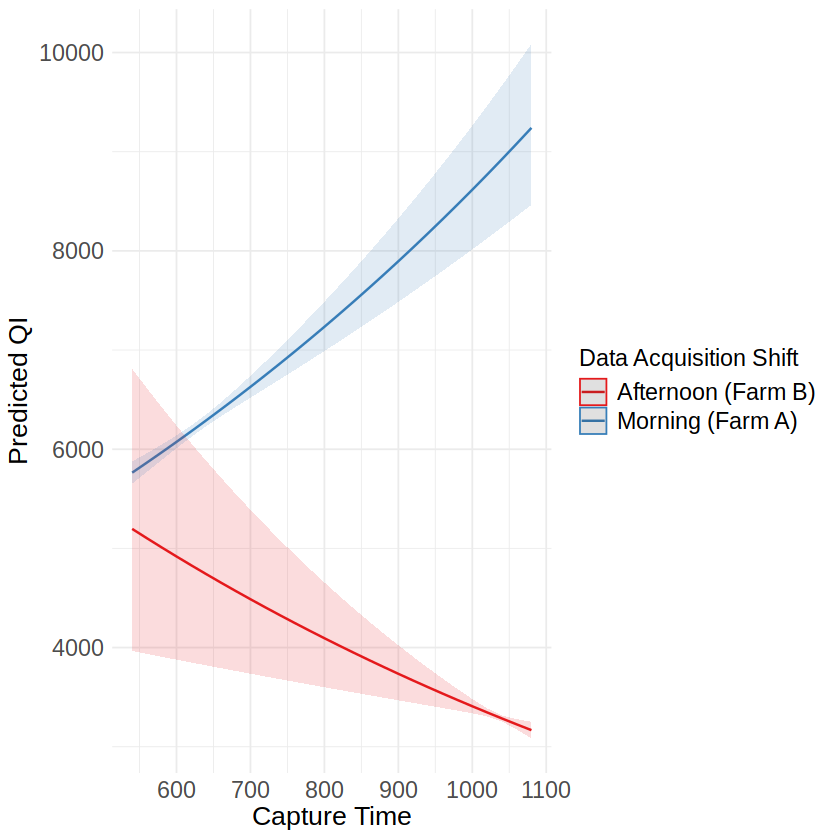

In [13]:
eff1 <- ggpredict(model2, terms = c("captured_at_as_min", "farm"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "Capture Time",
    y = "Predicted QI",
    color = "Data Acquisition Shift"
  ) +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 14)
  )

cha1
ggsave(
  "output/qi_effect_time_x_farm.png",
  cha1,
  width = 12,
  height = 6,
  dpi = 600,
)

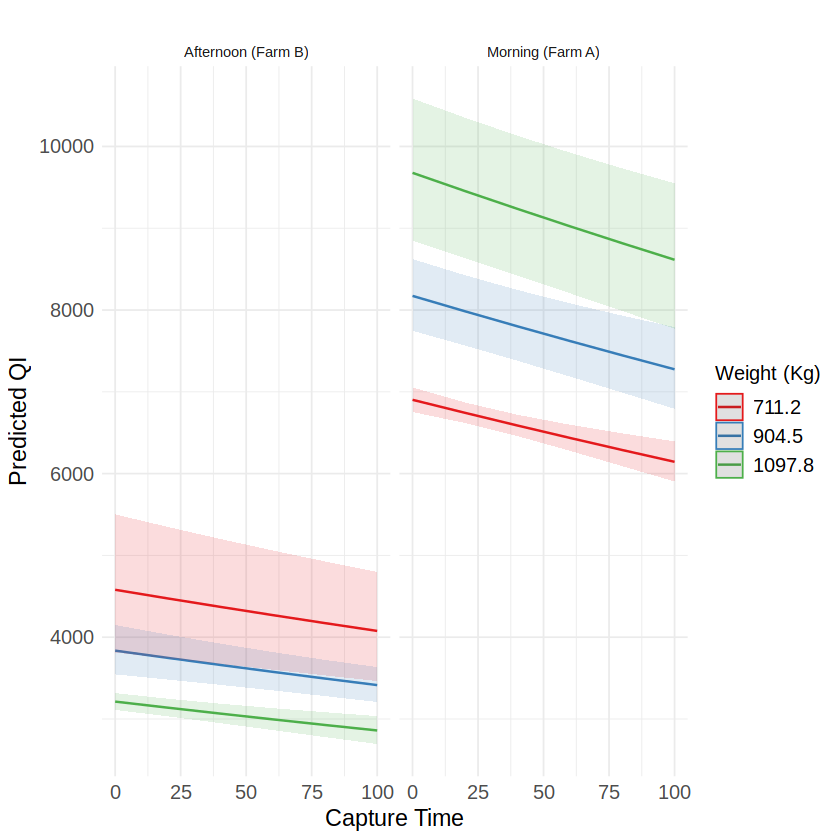

In [29]:
eff2 <- ggpredict(model2, terms = c("weight", "captured_at_as_min", "farm"))
plot(eff2) +
  labs(
    title = "",
    x = "Capture Time",
    y = "Predicted QI",
    color = "Weight (Kg)"
  ) +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 12)
  )